# Clustering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tslearn.metrics import cdist_dtw
from sklearn.metrics import silhouette_score, adjusted_rand_score

from src.plotting_functions import *
from src.column_spec import ColumnSpec
from src.clustering import *
from src.filters import *

In [2]:
# hme1_1      = pd.read_csv("../../Experiment/1_hTERT_HME1/Data/Processed/20260505_hTERT_HME1_1_processes_phosphoPlus.tsv", sep="\t").fillna(0)
hme1_2      = pd.read_csv("../../Experiment/2_hTERT_HME1/Data/Processed/20260505_hTERT_HEM1_2_processes_phosphoPlus.tsv", sep="\t").fillna(0)
# hek_1       = pd.read_csv("../../Experiment/1_HEK293T/Data/Processed/20260505_HEK293T_raw_selection_processes_phosphoPlus.tsv", sep="\t").fillna(0)
# hme1_mutants = pd.read_csv("../../Experiment/3_hTERT_HME1_mutants_comparison/Data/Processed/20260505_hTERT_HME1_mutants_test_processed_phosphoPlus_filtered.tsv", sep="\t").fillna(0)

## Parameters

Edit the cell below to change the dataset, conditions, and k-scan settings.
All downstream cells read from these variables.

In [3]:
# ════════════════════════════════════════════════════════════
# PARAMETERS — edit this cell to configure the full analysis
# ════════════════════════════════════════════════════════════

df_raw = hme1_2                      # dataset to cluster

CELL_LINES   = ["WT"]
CONDITIONS   = ["_EGF_", "_INS_", "_EGFnINS_"]
DATA_TYPE    = "log2:FC"
EXCLUDE_FULL = True

# Filtering
MIN_REPS = 2
MIN_FC   = 0.5                       # |log2FC| threshold (extremes mode)

# K-scan
K_RANGE  = range(5, 31, 5)           # k values to test: 5, 10, 15, 20, 25, 30
N_SEEDS  = 5                         # random seeds for stability estimate
MAX_ITER = 200                       # max iterations per run during the scan
N_INIT   = 5                         # number of initializations per k

# Final clustering (set after inspecting the k-scan summary)
K_FINAL     = 15
CLUSTER_COL = f"KMeans_{K_FINAL}clusters"

# ── Derived — do not edit ────────────────────────────────────────────────────
_scan_cols   = ColumnSpec.select(df_raw, cell_lines=CELL_LINES, data_type=DATA_TYPE,
                                  conditions=CONDITIONS, exclude_full=EXCLUDE_FULL,
                                  exclude_replicate_cols=True)
N_DIMS       = len(CELL_LINES) * len(CONDITIONS)
N_TIMEPOINTS = len(_scan_cols) // N_DIMS
print(f"Columns selected: {len(_scan_cols)}  |  Dimensions: {N_DIMS}  |  Timepoints per condition: {N_TIMEPOINTS}")

Columns selected: 18  |  Dimensions: 3  |  Timepoints per condition: 6


# Filtering data

In [4]:
df_filtered = filter_by_nreps(df_raw, min_reps=MIN_REPS)
print(f"After n:reps >= {MIN_REPS}:  {df_filtered.shape[0]} sites")

df_filtered = filter_dynamics(
    df           = df_filtered,
    cell_lines   = CELL_LINES,
    conditions   = CONDITIONS,
    data_type    = DATA_TYPE,
    threshold    = MIN_FC,
    mode         = "extremes",
    exclude_full = EXCLUDE_FULL,
)
print(f"After |FC| >= {MIN_FC}:      {df_filtered.shape[0]} sites")

After n:reps >= 2:  33719 sites
After |FC| >= 0.5:      12249 sites


## K-scan — finding the optimal number of clusters

For each k in `K_RANGE` and each random seed the loop collects:
- **Inertia** — total within-cluster DTW distance (seed 0). Lower = tighter. Look for an elbow.
- **Silhouette** — how much closer each site is to its own cluster than to the nearest other (seed 0, precomputed DTW matrix). Range ~0–1; 0.2–0.4 is typical for phosphoproteomics.
- **Stability** — mean pairwise ARI across all seed pairs. Higher = more reproducible at this k.

To use a different algorithm swap `clustering_fn` below:
- `tslearn_clustering_KShape` — drop the `metric` key from `clustering_kwargs`
- `kernnel_clustering` — rename `number_of_clusters` → `n_clusters` and `random_state` → `seed` in the loop call

In [ ]:
# ── Clustering function ─────────────────────────────────────────────────────
# Swap this line to test a different algorithm (see markdown above).
clustering_fn = tslearn_clustering_KMeans

# Generate a dictionary with all the variables that are going to be used in the clustering algorithms this way you do not have to repeat the same values everywhere
clustering_kwargs = dict(
    data_type                = DATA_TYPE,
    condition_for_clustering = CONDITIONS,
    cell_lines               = CELL_LINES,
    exclude_full             = EXCLUDE_FULL,
    df_dimensions            = N_DIMS,
    time_series_length       = N_TIMEPOINTS,
    transpose                = True,
    max_iterations           = MAX_ITER,
    n_init                   = N_INIT,
    metric                   = "euclidean",  # remove this line when using KShape
    verbose                  = False,
    testing                  = True,         # must be True to get model + multivariate
)

# ── Scan loop ────────────────────────────────────────────────────────────────
inertias, silhouettes, stabilities = [], [], []

for k in K_RANGE:
    labels_list = []

    for seed in range(N_SEEDS):
        _, model, multivariate = clustering_fn(
            df_to_cluster       = df_filtered.copy(),
            cluster_column_name = f"_kscan_k{k}_s{seed}",
            number_of_clusters  = k,
            random_state        = seed,
            **clustering_kwargs,
        )
        labels_list.append(model.labels_)

        if seed == 0:
            inertias.append(model.inertia_)
            D   = cdist_dtw(multivariate)
            sil = silhouette_score(D, model.labels_, metric="precomputed")
            silhouettes.append(sil)

    ari_scores = [
        adjusted_rand_score(labels_list[i], labels_list[j])
        for i in range(len(labels_list))
        for j in range(i + 1, len(labels_list))
    ]
    stabilities.append(np.mean(ari_scores))
    print(f"k={k:3d}  inertia={inertias[-1]:.4f}  silhouette={silhouettes[-1]:.4f}  stability={stabilities[-1]:.4f}")

In [ ]:
fig, axes = plot_kscan_summary(K_RANGE, inertias, silhouettes, stabilities)
plt.show()

### Load k-scan results from the server

The scripts in `scripts/` run the same k-scan in parallel on the calculation server and write a TSV with columns `k`, `inertia`, `silhouette`, `stability` — named `{prefix}_qc_metrics_{conditions}.tsv`.

Point `SERVER_RESULT` at one of those files to plot the full server scan instead of (or alongside) the local one above.

In [ ]:
SERVER_RESULT = "../../Server_results/20260310_calculations/20260310_kmeans_50clusters_qc_metrics_EGF+INS+EGFnINS.tsv"

server_df = pd.read_csv(SERVER_RESULT, sep="\t")

fig, axes = plot_kscan_summary(
    ks          = server_df["k"],
    inertias    = server_df["inertia"],
    silhouettes = server_df["silhouette"],
    stabilities = server_df["stability"],
)
plt.show()

## Final clustering

Set `K_FINAL` in the Parameters cell after inspecting the k-scan summary, then run this section.

In [5]:
df_clustered, clustering_model, multivariate, barycenters = tslearn_clustering_KMeans(
    df_to_cluster            = df_filtered.copy(),
    data_type                = DATA_TYPE,
    condition_for_clustering = CONDITIONS,
    cell_lines               = CELL_LINES,
    exclude_full             = EXCLUDE_FULL,
    stoichiometry            = None,
    cluster_column_name      = CLUSTER_COL,
    number_of_clusters       = 10, #K_FINAL
    max_iterations           = 1000,
    n_init                   = 10,
    metric                   = "euclidean",
    df_dimensions            = N_DIMS,
    time_series_length       = N_TIMEPOINTS,
    random_state             = 0,
    transpose                = True,
    verbose                  = True,
    testing                  = True,
    barycenter_calculations  = True,
)
print(f"\nCluster sizes:\n{df_clustered[CLUSTER_COL].value_counts().sort_index()}")

Column selection: ['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_5', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_15', 'WT_log2:FC_EGF_90', 'WT_log2:FC_INS_starve', 'WT_log2:FC_INS_2', 'WT_log2:FC_INS_5', 'WT_log2:FC_INS_10', 'WT_log2:FC_INS_15', 'WT_log2:FC_INS_90', 'WT_log2:FC_EGFnINS_starve', 'WT_log2:FC_EGFnINS_2', 'WT_log2:FC_EGFnINS_5', 'WT_log2:FC_EGFnINS_10', 'WT_log2:FC_EGFnINS_15', 'WT_log2:FC_EGFnINS_90']

Reshaping dataframe to shape (12249, 6, 3)

The size of the dataset is (12249, 6, 3)
Example:
[[ 0.          0.          0.        ]
 [-0.03027842 -0.20802001 -0.00251948]
 [ 0.38501691  0.2811497   0.60497242]
 [ 0.72058819  0.58861105  1.10215093]
 [ 0.26641739  1.17993274  1.33184657]
 [ 0.46116843  1.34451664  1.67753508]]
Init 1
1.115 --> 0.918 --> 0.897 --> 0.876 --> 0.865 --> 0.860 --> 0.856 --> 0.852 --> 0.849 --> 0.847 --> 0.845 --> 0.843 --> 0.842 --> 0.840 --> 0.839 --> 0.837 --> 0.836 --> 0.835 --> 0.834 --> 0.833 --> 0.832 --> 0.832 --> 0.832 --> 0.832 

## Cluster visualization

 Plot not saved


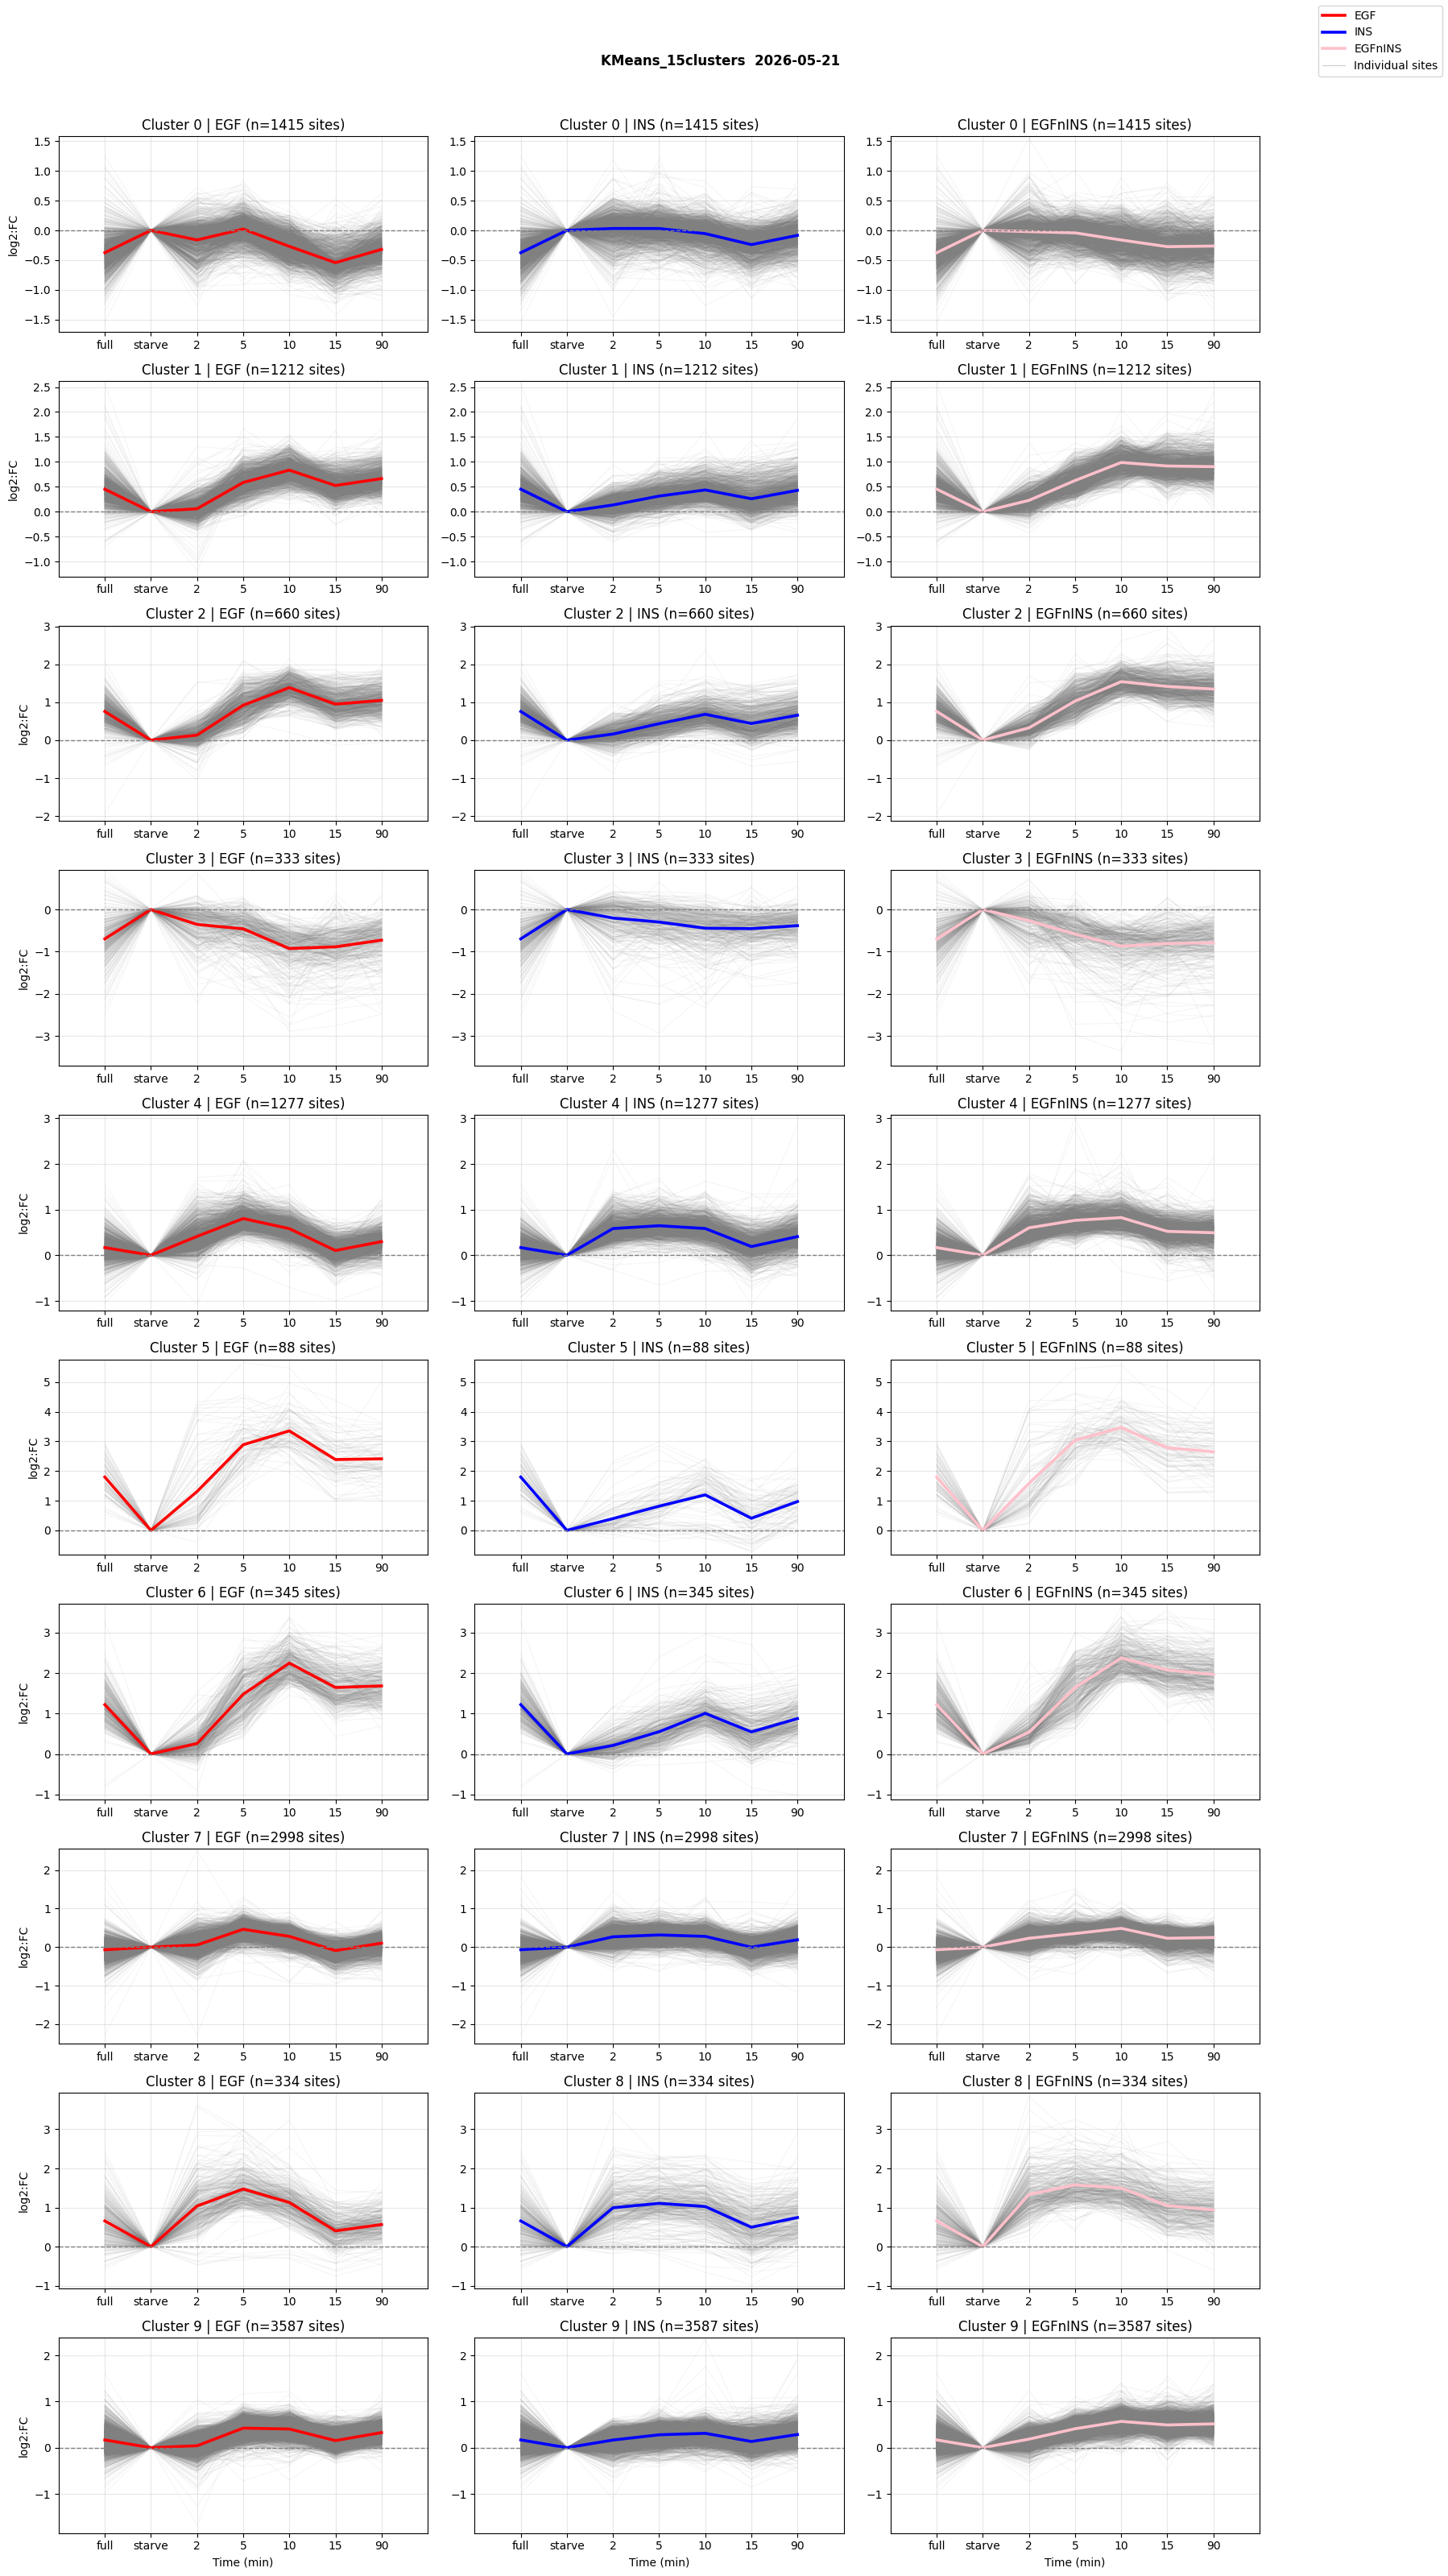

In [6]:
clusters_plot_linear_mutants(
    df                  = df_clustered,
    cluster_column      = CLUSTER_COL,
    data_type           = DATA_TYPE,
    cell_lines          = CELL_LINES,
    conditions          = CONDITIONS,
    colors              = {"_EGF_": "red", "_INS_": "blue", "_EGFnINS_": "pink"},
    panel_by            = "condition",
    plot_different_data = True,
    legend              = None,
    saving_path         = "",
    saving_info         = "",
    save_pdf            = False,
    save_png            = False,
    plot_close          = False,
    fit_y_lims          = False,
    grey_alpha          = 0.08,
    grey_lw             = 0.8,
    mean_lw             = 2.6,
)

## Cluster quality — within-cluster DTW dispersion

Lower bars mean tighter (more homogeneous) clusters per condition.

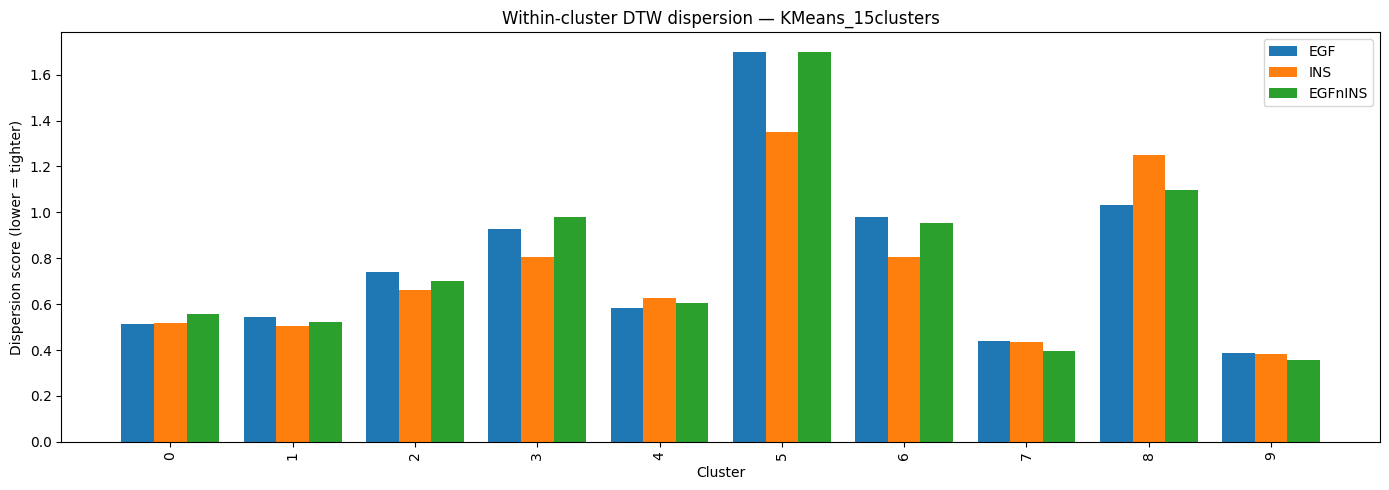

In [7]:
scores = cluster_similarity_per_condition(
    df                  = df_clustered,
    cell_lines          = CELL_LINES,
    conditions          = CONDITIONS,
    data_type           = DATA_TYPE,
    cluster_column_name = CLUSTER_COL,
    exclude_full        = EXCLUDE_FULL,
    transpose           = True,
)
fig, ax = plot_cluster_scores(
    scores,
    cond_order = [c.strip("_") for c in CONDITIONS],
    title      = f"Within-cluster DTW dispersion — {CLUSTER_COL}",
)
plt.show()

## Assignment confidence

Four views of how confidently each site was assigned to its cluster:

- **Distance-to-centroid heatmap** — rows are sites (sorted by cluster), columns are clusters; the assigned cluster should be the darkest cell in each row.
- **UMAP** — 2-D embedding of the distance-to-centroid matrix coloured by cluster; tight, well-separated blobs indicate clean assignments.
- **Margin histogram** — margin = (2nd-best distance) − (best distance); higher margin = more confident assignment. The orange line marks the 25th percentile (low-confidence sites).
- **Margin per cluster (boxplot)** — reveals which clusters are internally tight vs. ambiguous.

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


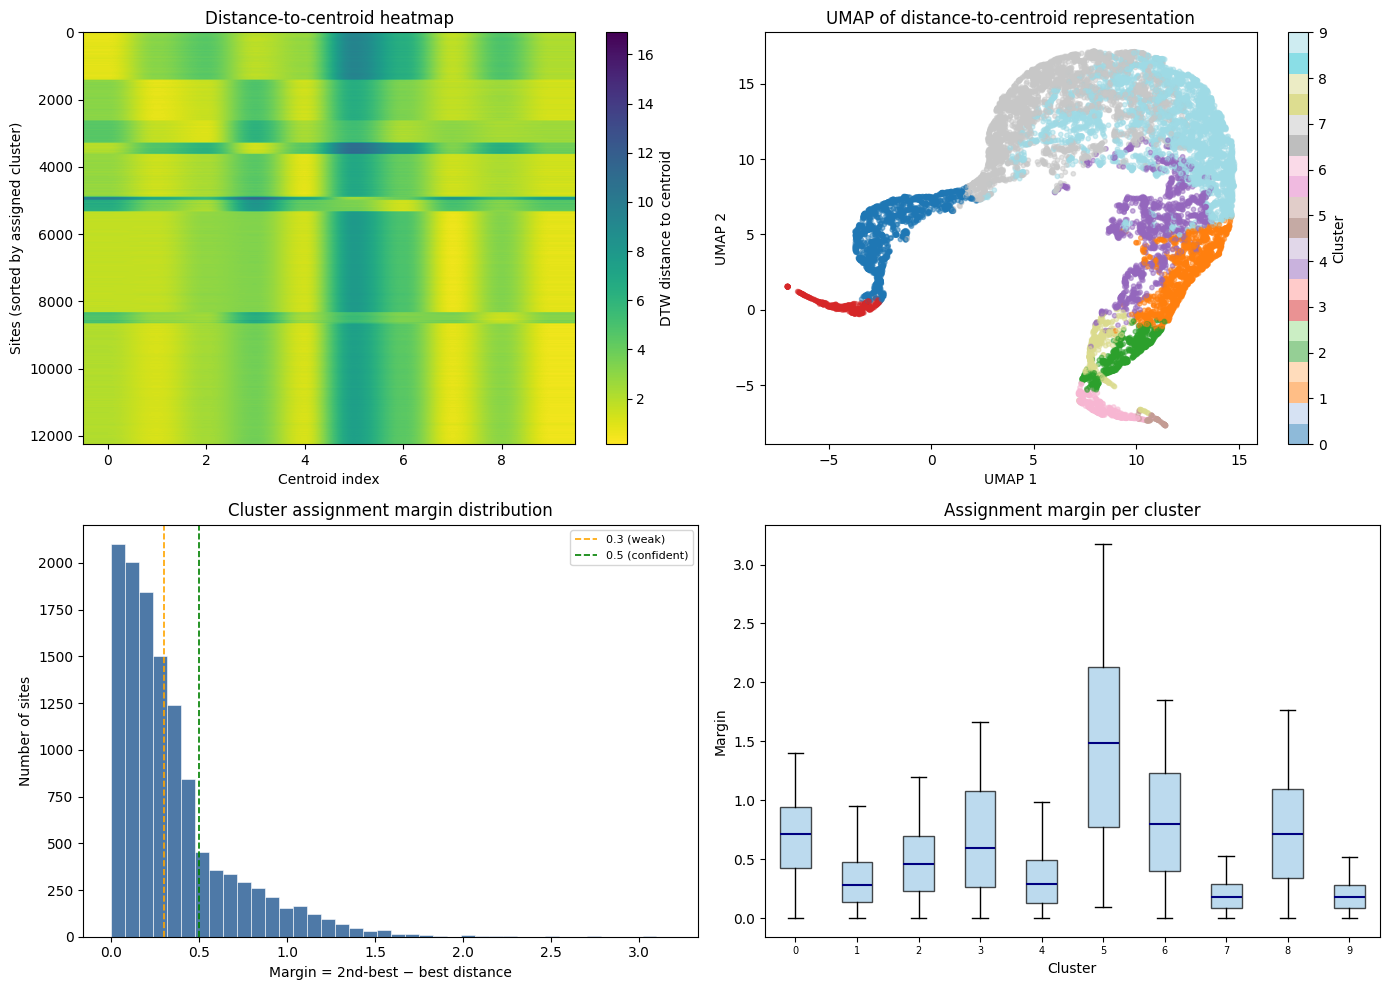

In [8]:
fig, axes = plot_cluster_assignment_qc(barycenters, clustering_model.labels_)
plt.show()

## Cluster hierarchy

KMeans assigns sites to clusters but gives them no inherent order.  This section imposes structure on the result by computing pairwise DTW distances **between the cluster centroids** and running hierarchical clustering on those distances.

Two outputs:
- **Dendrogram** — shows which KMeans clusters are similar to each other and at what DTW distance they merge into super-clusters.  Use the colour threshold to read off natural groupings.
- **Centroid grid** — the same centroid profiles as the cluster visualisation above, but rows are sorted by dendrogram leaf order so similar clusters appear adjacent.  The line colour matches the dendrogram super-cluster colour.

Useful for deciding whether to merge nearby clusters after the k-scan, and for producing a clean ordered summary of the final result.

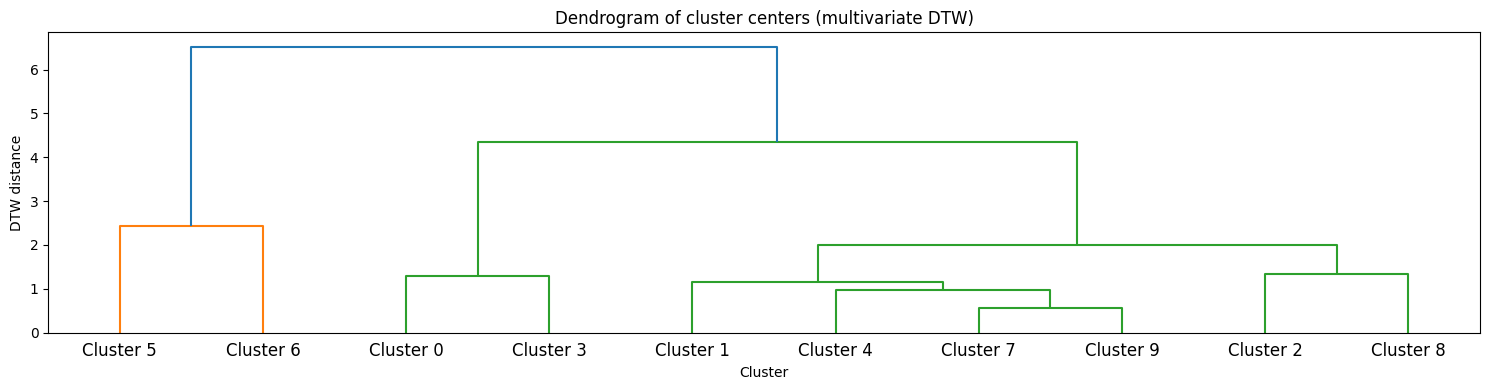

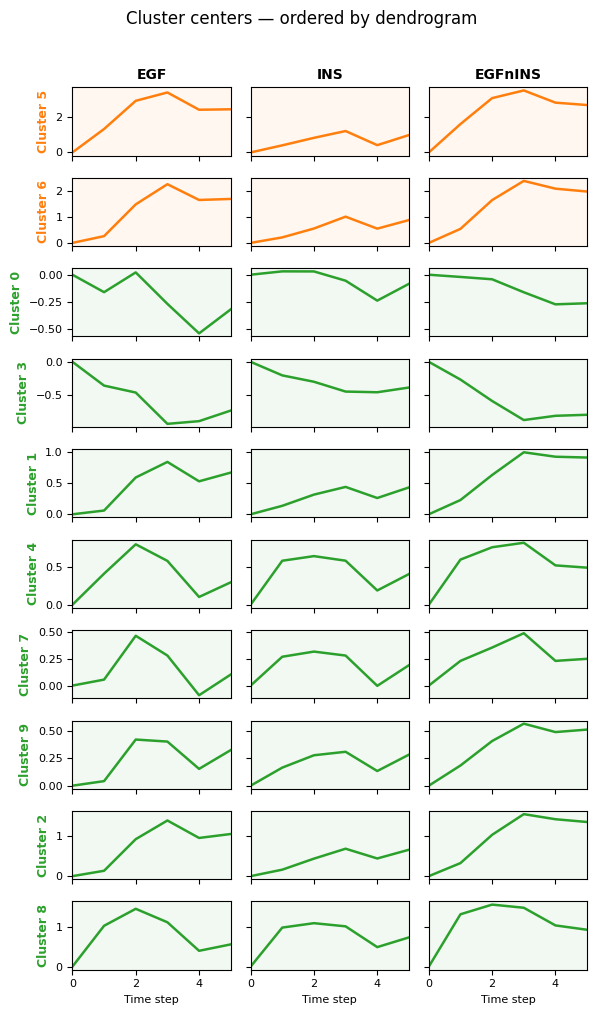

In [9]:
from src.clustering import compute_centroid_linkage

Z_hier, dist_matrix = compute_centroid_linkage(
    centers = clustering_model.cluster_centers_,
    method  = "weighted",
)

fig_dendro, fig_grid = plot_cluster_hierarchy(
    centers         = clustering_model.cluster_centers_,
    Z               = Z_hier,
    condition_names = [c.strip("_") for c in CONDITIONS],
    color_threshold = 0.7,
)
plt.show()